# 02a - Data Leakage Check & Cleanup

## Why this notebook exists

After running the full 22-model benchmark (`08_classical_full_benchmark.ipynb` +
`05_deep_learning.ipynb`), several models scored 99%+ test accuracy - suspiciously
high. Before treating those numbers as trustworthy evidence on the site, this
notebook checks the most common cause of "too good to be true" scores:
**train/test contamination**, where the exact same image appears in both splits.

This notebook:

1. Hashes every image in `train/`, `test/`, and (if it exists) the backup folder
   from a previous cleanup, and flags any **byte-for-byte identical** file that
   appears on both the train side and the test side - so re-running this
   notebook after cleanup already happened still reports the true, historical
   picture instead of "0 found" just because the files were already moved out.
2. Shows a few actual example pairs (with full file paths) side by side.
3. If a previous (contaminated) run already produced `docs/data/*.json`, cross-
   checks how much the leak actually inflated the reported accuracy - so the
   answer is measured, not assumed.
4. **Removes** the leaked duplicates from `train/` only (moved to a backup
   folder, never deleted) so every notebook downstream of this one trains on a
   contamination-free set. `test/` is left completely untouched.

**Run this notebook once**, right after `02_check_data_pipeline.ipynb` and
before `04_classical_ml.ipynb`, whenever `data/raw/` is freshly downloaded. It
is safe to re-run any number of times.

In [24]:
import hashlib
import json
import shutil
from pathlib import Path

import matplotlib.pyplot as plt
from PIL import Image

DATA_DIR = Path("../data/raw/casting_data/casting_data")
TRAIN_DIR = DATA_DIR / "train"
TEST_DIR = DATA_DIR / "test"

# Duplicates removed from train/ go here - deliberately OUTSIDE train/, so
# torchvision.datasets.ImageFolder never picks this up as a spurious 3rd class.
BACKUP_DIR = Path("../data/leaked_duplicates_removed_from_train")

CLASSES = ["def_front", "ok_front"]

RESULTS_DIR = Path("../results/metrics")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

## 1. Detect exact duplicates between `test/` and (`train/` + backup) (MD5)

Checks both possible locations for the train-side copy, so this always finds
the true, historical set of duplicates - whether or not a previous run of this
notebook already moved them into the backup folder.

In [25]:
def md5_of(path: Path) -> str:
    h = hashlib.md5()
    with open(path, "rb") as f:
        h.update(f.read())
    return h.hexdigest()


def find_duplicates_against_test(cls: str, source_dir: Path, tag: str):
    """Find files under source_dir that are byte-identical to a file in
    TEST_DIR/cls. Returns a list of (test_filename, source_filename, tag)
    triples. Uses a cheap file-size pre-filter before hashing."""
    if not source_dir.exists():
        return []

    test_dir = TEST_DIR / cls
    src_files = sorted(p.name for p in source_dir.iterdir() if p.is_file())
    test_files = sorted(p.name for p in test_dir.iterdir() if p.is_file())

    src_by_size = {}
    for fn in src_files:
        sz = (source_dir / fn).stat().st_size
        src_by_size.setdefault(sz, []).append(fn)

    dupes = []
    hash_cache = {}
    for fn in test_files:
        test_path = test_dir / fn
        sz = test_path.stat().st_size
        candidates = src_by_size.get(sz, [])
        if not candidates:
            continue
        test_hash = md5_of(test_path)
        for cfn in candidates:
            key = (cfn, sz)
            if key not in hash_cache:
                hash_cache[key] = md5_of(source_dir / cfn)
            if hash_cache[key] == test_hash:
                dupes.append((fn, cfn, tag))
                break

    return dupes


leak_report = {}
for cls in CLASSES:
    train_files = sorted(p.name for p in (TRAIN_DIR / cls).iterdir() if p.is_file())
    test_files = sorted(p.name for p in (TEST_DIR / cls).iterdir() if p.is_file())

    live_dupes = find_duplicates_against_test(cls, TRAIN_DIR / cls, "train")
    backup_dupes = find_duplicates_against_test(cls, BACKUP_DIR / cls, "backup")
    all_pairs = live_dupes + backup_dupes

    leak_report[cls] = {
        "train_n": len(train_files),
        "test_n": len(test_files),
        "duplicate_count": len(all_pairs),
        "duplicate_pct_of_test": round(100 * len(all_pairs) / len(test_files), 1),
        "pairs": all_pairs,  # (test_filename, source_filename, "train" | "backup")
        "pending_removal": len(live_dupes),
        "already_removed": len(backup_dupes),
    }
    print(
        f"{cls}: train={len(train_files)} test={len(test_files)}  "
        f"duplicates found: {len(all_pairs)} total "
        f"({len(live_dupes)} still in train/, {len(backup_dupes)} already "
        f"moved to backup/) - {leak_report[cls]['duplicate_pct_of_test']}% of test"
    )

def_front: train=3758 test=453  duplicates found: 0 total (0 still in train/, 0 already moved to backup/) - 0.0% of test
ok_front: train=2811 test=262  duplicates found: 64 total (0 still in train/, 64 already moved to backup/) - 24.4% of test


### Example duplicate pairs (with file paths)

A few concrete examples, so this isn't just a number - each pair below is the
**same file** living in 2 places: the test split, and either `train/` (not yet
cleaned up) or the backup folder (already moved out by a previous run).

Pair 1 (already in backup/):
  train-side: D:\Casting Quality Inspection\data\leaked_duplicates_removed_from_train\ok_front\cast_ok_0_1001.jpeg
  test-side:  D:\Casting Quality Inspection\data\raw\casting_data\casting_data\test\ok_front\cast_ok_0_1001.jpeg

Pair 2 (already in backup/):
  train-side: D:\Casting Quality Inspection\data\leaked_duplicates_removed_from_train\ok_front\cast_ok_0_1002.jpeg
  test-side:  D:\Casting Quality Inspection\data\raw\casting_data\casting_data\test\ok_front\cast_ok_0_1002.jpeg

Pair 3 (already in backup/):
  train-side: D:\Casting Quality Inspection\data\leaked_duplicates_removed_from_train\ok_front\cast_ok_0_1003.jpeg
  test-side:  D:\Casting Quality Inspection\data\raw\casting_data\casting_data\test\ok_front\cast_ok_0_1003.jpeg

Pair 4 (already in backup/):
  train-side: D:\Casting Quality Inspection\data\leaked_duplicates_removed_from_train\ok_front\cast_ok_0_1019.jpeg
  test-side:  D:\Casting Quality Inspection\data\raw\casting_data\casting_data\tes

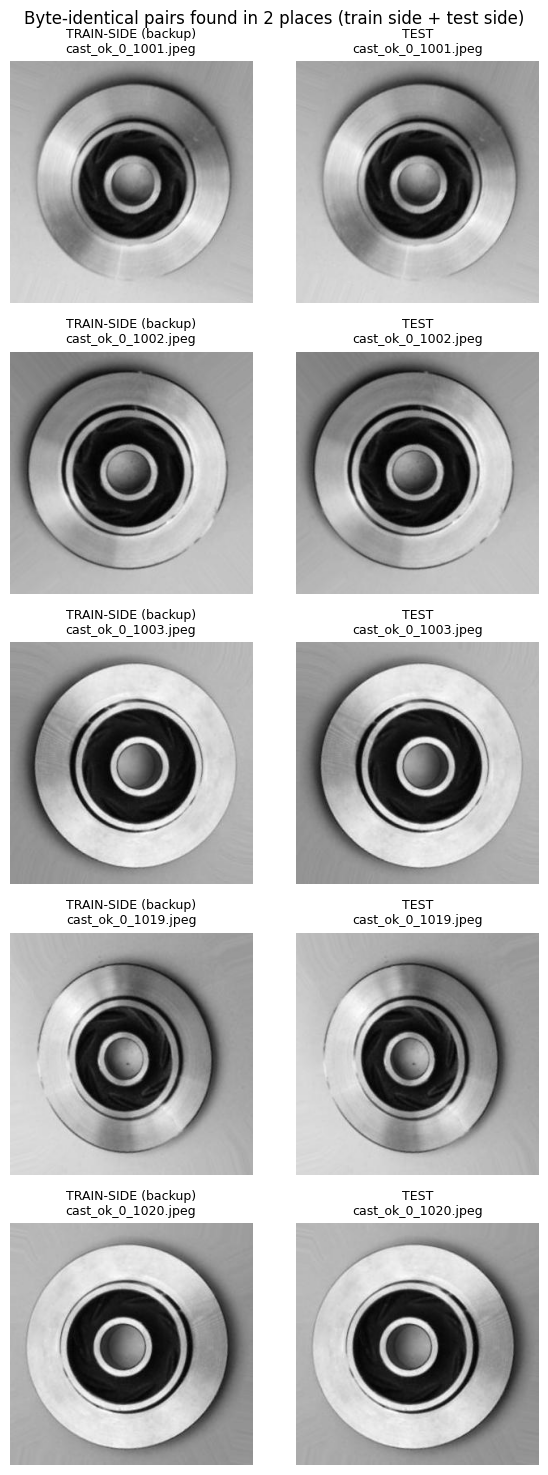


⚠️  WARNING: these pairs are byte-for-byte identical - the model sees the
exact same file during training AND again at test time. A test image that was
also in training is not a valid measure of generalization on its own, which
can inflate the *reported* test accuracy for the class/model it belongs to.
Section 2 below quantifies exactly how large that effect actually is, using the
prior (contaminated) run's saved predictions.


In [26]:
N_EXAMPLES = 5
example_pairs = leak_report["ok_front"]["pairs"][:N_EXAMPLES]

if not example_pairs:
    print("No duplicate pairs found for ok_front - nothing to show.")
else:
    fig, axes = plt.subplots(len(example_pairs), 2, figsize=(6, 3 * len(example_pairs)))
    if len(example_pairs) == 1:
        axes = axes.reshape(1, 2)

    for i, (test_fn, src_fn, tag) in enumerate(example_pairs):
        source_dir = TRAIN_DIR / "ok_front" if tag == "train" else BACKUP_DIR / "ok_front"
        train_side_path = (source_dir / src_fn).resolve()
        test_path = (TEST_DIR / "ok_front" / test_fn).resolve()

        print(f"Pair {i + 1} ({'still in train/' if tag == 'train' else 'already in backup/'}):")
        print(f"  train-side: {train_side_path}")
        print(f"  test-side:  {test_path}")
        print()

        axes[i, 0].imshow(Image.open(train_side_path))
        axes[i, 0].set_title(f"TRAIN-SIDE ({tag})\n{src_fn}", fontsize=9)
        axes[i, 0].axis("off")

        axes[i, 1].imshow(Image.open(test_path))
        axes[i, 1].set_title(f"TEST\n{test_fn}", fontsize=9)
        axes[i, 1].axis("off")

    plt.suptitle("Byte-identical pairs found in 2 places (train side + test side)")
    plt.tight_layout()
    plt.show()

    print(
        "\n\u26a0\ufe0f  WARNING: these pairs are byte-for-byte identical - the "
        "model sees the\n"
        "exact same file during training AND again at test time. A test image "
        "that was\n"
        "also in training is not a valid measure of generalization on its "
        "own, which\n"
        "can inflate the *reported* test accuracy for the class/model it "
        "belongs to.\n"
        "Section 2 below quantifies exactly how large that effect actually is, "
        "using the\n"
        "prior (contaminated) run's saved predictions."
    )

## 2. How much does this actually inflate the reported accuracy?

If `docs/data/predictions.json` already exists from a previous (contaminated)
run of `09_export_web_assets.ipynb`, recompute every model's accuracy with the
leaked images excluded, and compare. This is purely diagnostic - it does not
write anything - and is skipped automatically the very first time this
pipeline ever runs (no prior results to compare against yet).

In [27]:
PRED_PATH = Path("../docs/data/predictions.json")
IMAGES_PATH = Path("../docs/data/images.json")
MODELS_PATH = Path("../docs/data/models.json")

if PRED_PATH.exists() and IMAGES_PATH.exists() and MODELS_PATH.exists():
    images_meta = json.loads(IMAGES_PATH.read_text())
    predictions = json.loads(PRED_PATH.read_text())
    models_meta = json.loads(MODELS_PATH.read_text())

    id2label = {im["id"]: im["true_label"] for im in images_meta}

    # images.json is written in test_paths order, and ImageFolder always lists
    # classes alphabetically (def_front, then ok_front) with filenames sorted
    # within each - so the leaked ok_front test filenames map onto a
    # contiguous id range starting right after the last def_front id.
    n_def = sum(1 for v in id2label.values() if v == "def_front")
    ok_dupe_test_filenames = {test_fn for test_fn, _, _ in leak_report["ok_front"]["pairs"]}
    ok_front_sorted_test_files = sorted(
        p.name for p in (TEST_DIR / "ok_front").iterdir() if p.is_file()
    )
    leaked_ids = {
        f"img_{n_def + pos:03d}"
        for pos, fn in enumerate(ok_front_sorted_test_files)
        if fn in ok_dupe_test_filenames
    }

    rows = []
    for m in models_meta:
        mid = m["model_id"]
        correct_full = correct_clean = n_clean = 0
        for img_id, label in id2label.items():
            p = predictions.get(img_id, {}).get(mid)
            if not p:
                continue
            hit = p["pred"] == label
            correct_full += hit
            if img_id not in leaked_ids:
                correct_clean += hit
                n_clean += 1
        acc_full = correct_full / len(id2label)
        acc_clean = correct_clean / n_clean
        rows.append((m["display_name"], acc_full, acc_clean))

    rows.sort(key=lambda r: -r[1])
    print(f"{'model':32s} {'acc (with leak)':>16s} {'acc (leak removed)':>20s} {'delta':>8s}")
    for name, full, clean in rows:
        print(f"{name:32s} {full*100:15.2f}% {clean*100:19.2f}% {(full-clean)*100:+7.2f}pp")
else:
    print(
        "No prior docs/data/*.json found - skipping the before/after "
        "comparison (expected on the very first run of this pipeline). "
        "Run 04 onward, then re-run this cell later if you want the "
        "comparison."
    )

model                             acc (with leak)   acc (leak removed)    delta
ResNet18                                   99.86%               99.85%   +0.01pp
Histogram + SVM                            99.86%               99.85%   +0.01pp
Histogram + Random Forest                  99.58%               99.54%   +0.04pp
HOG + SVM                                  99.30%               99.23%   +0.07pp
Raw Pixels + SVM                           99.16%               99.39%   -0.22pp
Raw Pixels + Random Forest                 98.46%               98.31%   +0.15pp
HOG + Random Forest                        98.32%               98.16%   +0.16pp
HOG + Logistic Regression                  97.34%               97.08%   +0.26pp
Histogram + Logistic Regression            95.52%               95.24%   +0.29pp
Sobel + Random Forest                      93.29%               92.63%   +0.66pp
Raw Pixels + Logistic Regression           92.73%               92.01%   +0.71pp
Sobel + SVM                  

## 3. Remove the leaked duplicates from `train/` (backup, never delete)

Only files still sitting in `train/` get moved (pairs already in the backup
folder from a previous run are skipped). `test/` is never touched.

In [28]:
BACKUP_DIR.mkdir(parents=True, exist_ok=True)

total_moved = 0
for cls in CLASSES:
    live_pairs = [(test_fn, src_fn) for test_fn, src_fn, tag in leak_report[cls]["pairs"] if tag == "train"]
    if not live_pairs:
        continue
    cls_backup = BACKUP_DIR / cls
    cls_backup.mkdir(parents=True, exist_ok=True)
    moved = []
    for test_fn, train_fn in live_pairs:
        src = TRAIN_DIR / cls / train_fn
        if not src.exists():
            continue  # already moved by a previous run of this notebook
        dst = cls_backup / train_fn
        shutil.move(str(src), str(dst))
        moved.append(train_fn)
        total_moved += 1
    print(f"{cls}: moved {len(moved)} duplicate file(s) out of train/ -> {cls_backup}")

print(f"\nTotal moved this run: {total_moved}")
print("(Safe to re-run this notebook - already-moved files are detected and skipped.)")


Total moved this run: 0
(Safe to re-run this notebook - already-moved files are detected and skipped.)


## 4. Verify the fix and save a permanent report

In [29]:
def find_train_test_overlap(cls: str):
    """Simple train/ vs test/ check only (ignores the backup folder) - used
    here purely to confirm train/ itself no longer overlaps test/."""
    return find_duplicates_against_test(cls, TRAIN_DIR / cls, "train")


print("Re-checking train/ vs test/ after cleanup...\n")
after = {}
for cls in CLASSES:
    remaining = find_train_test_overlap(cls)
    train_n_now = len(list((TRAIN_DIR / cls).glob("*")))
    test_n_now = len(list((TEST_DIR / cls).glob("*")))
    after[cls] = {"train_n": train_n_now, "test_n": test_n_now, "duplicate_count": len(remaining)}
    print(
        f"{cls}: train={train_n_now} (was {leak_report[cls]['train_n']})  "
        f"test={test_n_now}  remaining train/test overlap: {len(remaining)}"
    )
    assert len(remaining) == 0, f"Cleanup incomplete for {cls}!"

print("\nAll clear - train/ and test/ no longer share any identical images.")

report = {
    "detected_total": {
        cls: {k: v for k, v in leak_report[cls].items() if k != "pairs"}
        for cls in CLASSES
    },
    "all_pairs_ever_found": {cls: leak_report[cls]["pairs"] for cls in CLASSES},
    "after_cleanup": after,
}
report_path = RESULTS_DIR / "leakage_check_report.json"
report_path.write_text(json.dumps(report, indent=2))
print(f"\nSaved full report to {report_path}")

Re-checking train/ vs test/ after cleanup...

def_front: train=3758 (was 3758)  test=453  remaining train/test overlap: 0
ok_front: train=2811 (was 2811)  test=262  remaining train/test overlap: 0

All clear - train/ and test/ no longer share any identical images.

Saved full report to ..\results\metrics\leakage_check_report.json


## Next step

`train/` is now leak-free; `test/` was never touched. Re-run the rest of the
pipeline in order so every downstream artifact reflects the clean data:

`04_classical_ml.ipynb` -> `05_deep_learning.ipynb` -> `06_model_testing.ipynb`
-> `07_error_analysis.ipynb` -> `08_classical_full_benchmark.ipynb` ->
`09_export_web_assets.ipynb`

(`03_classical_features.ipynb` only visualizes feature extraction for
explanatory purposes and doesn't feed into training, so re-running it is
optional.)

This will overwrite `../models/classical/*.joblib`, `../models/resnet18_casting.pt`,
`../results/`, and `../docs/data/*.json` + `../docs/assets/` with numbers
computed on the deduplicated training set. No code changes are needed in any
of those notebooks - they all load images fresh from `train/`/`test/` on
every run, so they automatically pick up the smaller, clean `train/ok_front/`.